# CIFAR10 with MLPs
Simple starter notebook to benchmark your own MLP with PyTorch on the CIFAR-10 dataset.

Testeeeeee


OBS.:

- The main code is basically done, so focus on training the models and searching for the best hyperparameters and architectures.
- You are not required to use this exact code or even the PyTorch library.
- It is recommended to use execution environments with GPU access (such as Google Colab), since larger models will take more time to train.
- Remember to document the history of your experiments and which results motivated the changes in subsequent experiments.

In [11]:
pip install optuna -q

In [12]:
#@title Libs

import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
# import skelearn mlp with C implementation


from tqdm import tqdm

import optuna
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

In [13]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)


In [14]:
subset_size = 10000 # subconjunto pra ir mais rápido

train_indices = list(range(len(train_dataset)))
train_labels = [train_dataset[i][1] for i in train_indices]

search_indices, _ = train_test_split(
    train_indices,
    train_size=subset_size,
    stratify=train_labels, # garante a mesma quantidade por classe
    random_state=42
)

search_dataset = Subset(train_dataset, search_indices) # só no optuna

print(f"subconjunto de busca criado com {len(search_dataset)} imagens.")
print(f"representa {len(search_dataset)//10} imagens por classe.")

subconjunto de busca criado com 10000 imagens.
representa 1000 imagens por classe.


In [15]:
class MLP(nn.Module):
    def __init__(self, input_size, num_classes, hidden_sizes, dropout_rate, activation_func):
        super(MLP, self).__init__()
        layers = []
        in_features = input_size

        for h_size in hidden_sizes:
            layers.append(nn.Linear(in_features, h_size))
            layers.append(activation_func)
            layers.append(nn.Dropout(dropout_rate))
            in_features = h_size

        layers.append(nn.Linear(in_features, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [16]:
def get_scores(targets, predictions):
    return {
        "accuracy": metrics.accuracy_score(targets, predictions),
        "balanced_accuracy": metrics.balanced_accuracy_score(targets, predictions),
        "precision": metrics.precision_score(targets, predictions, average="weighted"),
        "recall": metrics.recall_score(targets, predictions, average="weighted"),
        "f1_score": metrics.f1_score(targets, predictions, average="weighted")
    }

In [17]:
def objective(trial):
    arch_dict = {
            "Original_Losango": (64, 128, 64),
            "Funil_Largo": (256, 128, 64),
            #"Larga_Rasa": (512, 256),
            "Grande": (1024, 512, 256, 128),
            "Enorme": (2048, 1024, 512, 256, 128),
            "Via": (2048, 256)
        }

    arch_name = trial.suggest_categorical("arch_name", list(arch_dict.keys()))
    hidden_sizes = arch_dict[arch_name]

    dropout_rate = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    activation_name = trial.suggest_categorical("activation", ["ReLU", "Tanh"])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    activations = {"ReLU": nn.ReLU(), "Tanh": nn.Tanh()}

    print(f"Iniciando Trial #{trial.number}")
    print(f"Arquitetura: {arch_name} {hidden_sizes}")
    print(f"Otimizador: {optimizer_name} | LR: {lr:.5f} | Dropout: {dropout_rate:.2f}")

    k_folds = 3
    kfold = KFold(n_splits=k_folds, shuffle=True)
    fold_accuracies = []

    for fold, (train_ids, val_ids) in enumerate(kfold.split(search_dataset)):
        train_sub = Subset(search_dataset, train_ids)
        val_sub = Subset(search_dataset, val_ids)
        t_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
        v_loader = DataLoader(val_sub, batch_size=batch_size, shuffle=False)

        model = MLP(3072, 10, hidden_sizes, dropout_rate, activations[activation_name]).cuda()
        optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), lr=lr)

        # loop de treino curto
        for epoch in range(5):
            model.train()
            for images, labels in t_loader:
                images = images.view(-1, 3072).cuda()
                labels = labels.cuda()

                optimizer.zero_grad()
                outputs = model(images)

                loss = nn.CrossEntropyLoss()(outputs, labels)
                loss.backward()
                optimizer.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in v_loader:
                images = images.view(-1, 3072).cuda()
                outputs = model(images)
                pred = outputs.argmax(dim=1)
                correct += pred.eq(labels.cuda()).sum().item()

        acc = correct / len(val_ids)
        fold_accuracies.append(acc)
        print(f"  > Fold {fold+1}/{k_folds} finalizado. Acurácia: {acc:.4f}")

    mean_accuracy = np.mean(fold_accuracies)

    print(f"RESULTADO TRIAL #{trial.number}: Acurácia Média (CV) = {mean_accuracy:.4f}")

    return mean_accuracy

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def final_evaluation(best_model, test_loader):
    best_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(-1, 3072).cuda()
            outputs = best_model(images)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    # acurácia por classe e métricas totais
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

    # Matriz de Confusão
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

In [19]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print(f"Melhor Acurácia de Validação: {study.best_value:.4f}")
print(f"Melhores Parâmetros: {study.best_params}")

[I 2026-03-21 21:19:33,395] A new study created in memory with name: no-name-35c43411-1bd7-42f5-a683-c54a62a2a5bc


Iniciando Trial #0
Arquitetura: Funil_Largo (256, 128, 64)
Otimizador: SGD | LR: 0.00035 | Dropout: 0.24
  > Fold 1/3 finalizado. Acurácia: 0.2340
  > Fold 2/3 finalizado. Acurácia: 0.2163


[I 2026-03-21 21:20:13,382] Trial 0 finished with value: 0.22579918459752393 and parameters: {'arch_name': 'Funil_Largo', 'dropout': 0.24060960268261758, 'lr': 0.0003486387232348251, 'activation': 'Tanh', 'optimizer': 'SGD', 'batch_size': 16}. Best is trial 0 with value: 0.22579918459752393.


  > Fold 3/3 finalizado. Acurácia: 0.2271
RESULTADO TRIAL #0: Acurácia Média (CV) = 0.2258
Iniciando Trial #1
Arquitetura: Funil_Largo (256, 128, 64)
Otimizador: Adam | LR: 0.00403 | Dropout: 0.40
  > Fold 1/3 finalizado. Acurácia: 0.2864
  > Fold 2/3 finalizado. Acurácia: 0.2949


[I 2026-03-21 21:20:53,479] Trial 1 finished with value: 0.28750010573942814 and parameters: {'arch_name': 'Funil_Largo', 'dropout': 0.3966494459218929, 'lr': 0.0040336942147642715, 'activation': 'Tanh', 'optimizer': 'Adam', 'batch_size': 16}. Best is trial 1 with value: 0.28750010573942814.


...

  > Fold 3/3 finalizado. Acurácia: 0.4446
RESULTADO TRIAL #97: Acurácia Média (CV) = 0.4450
Iniciando Trial #98
Arquitetura: Enorme (2048, 1024, 512, 256, 128)
Otimizador: Adam | LR: 0.00023 | Dropout: 0.11
  > Fold 1/3 finalizado. Acurácia: 0.4199
  > Fold 2/3 finalizado. Acurácia: 0.4155


[I 2026-03-21 22:07:37,738] Trial 98 finished with value: 0.42020002840116044 and parameters: {'arch_name': 'Enorme', 'dropout': 0.10718209865293295, 'lr': 0.00022662805696525726, 'activation': 'ReLU', 'optimizer': 'Adam', 'batch_size': 16}. Best is trial 86 with value: 0.44750029892011395.


  > Fold 3/3 finalizado. Acurácia: 0.4251
RESULTADO TRIAL #98: Acurácia Média (CV) = 0.4202
Iniciando Trial #99
Arquitetura: Via (2048, 256)
Otimizador: Adam | LR: 0.00017 | Dropout: 0.13
  > Fold 1/3 finalizado. Acurácia: 0.4388
  > Fold 2/3 finalizado. Acurácia: 0.4479


[I 2026-03-21 22:08:14,616] Trial 99 finished with value: 0.4417002888051253 and parameters: {'arch_name': 'Via', 'dropout': 0.12671763531652613, 'lr': 0.0001737776159804617, 'activation': 'ReLU', 'optimizer': 'Adam', 'batch_size': 16}. Best is trial 86 with value: 0.44750029892011395.


  > Fold 3/3 finalizado. Acurácia: 0.4383
RESULTADO TRIAL #99: Acurácia Média (CV) = 0.4417
Melhor Acurácia de Validação: 0.4475
Melhores Parâmetros: {'arch_name': 'Via', 'dropout': 0.11754249162316896, 'lr': 0.00015112309615373848, 'activation': 'ReLU', 'optimizer': 'Adam', 'batch_size': 64}



Treinando o modelo final
Parâmetros Otimizados: {'arch_name': 'Via', 'dropout': 0.11754249162316896, 'lr': 0.00015112309615373848, 'activation': 'ReLU', 'optimizer': 'Adam', 'batch_size': 64}


Época 1 finalizada. Loss Média: 1.6440


Época 2 finalizada. Loss Média: 1.4281


Época 3 finalizada. Loss Média: 1.3237


Época 4 finalizada. Loss Média: 1.2369


...

Época 58 finalizada. Loss Média: 0.1148


Época 59 finalizada. Loss Média: 0.1061


Época 60 finalizada. Loss Média: 0.1076


Época 61 finalizada. Loss Média: 0.1092


Época 62 finalizada. Loss Média: 0.1045

 Early Stopping ativado na época 62.
              precision    recall  f1-score   support

    airplane       0.64      0.69      0.66      1000
  automobile       0.69      0.69      0.69      1000
        bird       0.48      0.46      0.47      1000
         cat       0.38      0.37      0.38      1000
        deer       0.54      0.47      0.50      1000
         dog       0.42      0.55      0.47      1000
        frog       0.64      0.60      0.62      1000
       horse       0.68      0.58      0.62      1000
        ship       0.69      0.71      0.70      1000
       truck       0.60      0.61      0.61      1000

    accuracy                           0.57     10000
   macro avg       0.58      0.57      0.57     10000
weighted avg       0.58      0.57      0.57     10000



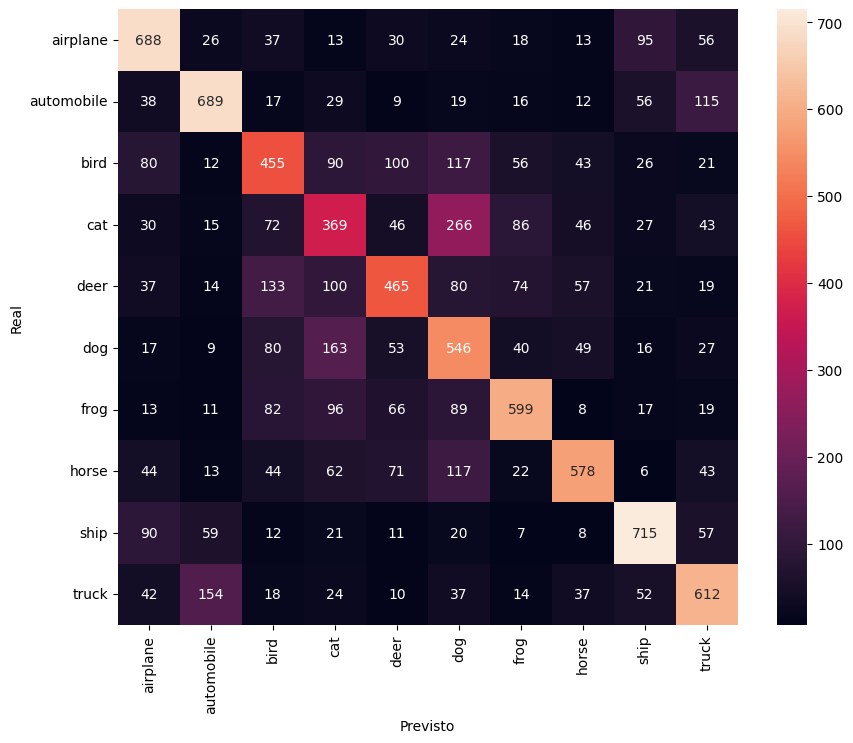

In [23]:
df_results = study.trials_dataframe()
df_results.to_csv("experimentos_mlp_optuna.csv", index=False)

best_params = study.best_params
activations = {"ReLU": nn.ReLU(), "Tanh": nn.Tanh()}

arch_dict = {
        "Original_Losango": (64, 128, 64),
        "Funil_Largo": (256, 128, 64),
        #"Larga_Rasa": (512, 256),
        "Grande": (1024, 512, 256, 128),
        "Enorme": (2048, 1024, 512, 256, 128),
        "Via": (2048, 256)
    }
best_arch_name = best_params["arch_name"]  # Aqui está o nome (ex: 'Larga_Rasa')
best_hidden_sizes = arch_dict[best_arch_name] # Aqui pegamos a tupla (512, 256)

print(f"\nTreinando o modelo final")
print(f"Parâmetros Otimizados: {best_params}")

# arquitetura vencedora
best_model = MLP(
    input_size=3072,
    num_classes=10,
    hidden_sizes=best_hidden_sizes,
    dropout_rate=study.best_params["dropout"],
    activation_func=activations[study.best_params["activation"]]
).cuda() # gpu

optimizer = getattr(torch.optim, best_params["optimizer"])(best_model.parameters(), lr=best_params["lr"])
full_train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# treino final
best_loss = float('inf')
patience = 5
patience_counter = 0
max_epochs = 100
best_model_path = 'melhor_modelo_mlp_final.pth'

for epoch in range(max_epochs):
    best_model.train()
    epoch_loss = 0.0

    for images, labels in tqdm(full_train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False):
        images = images.view(-1, 3072).cuda()
        labels = labels.cuda()

        optimizer.zero_grad()
        outputs = best_model(images)

        loss = nn.CrossEntropyLoss()(outputs, labels)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(full_train_loader)
    print(f"Época {epoch+1} finalizada. Loss Média: {avg_epoch_loss:.4f}")

    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
        torch.save(best_model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n Early Stopping ativado na época {epoch+1}.")
            break

# avaliação final
best_model.load_state_dict(torch.load(best_model_path))
final_evaluation(best_model, DataLoader(test_dataset, batch_size=64, shuffle=False))